In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

In [8]:
def analyze_p_treshold(df):

    df = df[df['with_query_flag'] == 'mix']
    #uses appropriate diversity metrics, other options are yes or no.
    # with_query_flag == "yes" will compute diversity also on the basis of distance between query tuples.
    # with_query_flag == "no" will compute only among the data lake tuples.
    # with_query_flag == "mix" computes withing data lake tuples and between query and data lake tuples. 
    # Compute mean scores
    summary = df.groupby('algorithm')[['max-min_div_score', 'avg_div_score']].mean().reset_index()
    summary['p'] = summary['algorithm'].str.extract(r'p=(\d+)').astype(float)
    summary = summary.sort_values('p').reset_index(drop=True)

    # Compute % change from previous p and set p=1 to 0%
    summary['%_change_maxmin'] = summary['max-min_div_score'].pct_change().fillna(0) * 100
    summary['%_change_avgdiv'] = summary['avg_div_score'].pct_change().fillna(0) * 100
    summary['%_combined_improve'] = (summary['%_change_maxmin'] + summary['%_change_avgdiv']) / 2

    # Print table
    print("\nDiversity Score Summary and Percentage Changes (from previous p):")
    print(f"{'p':<6} {'max-min_avg':<15} {'avg-div_avg':<12} {'%Δ max-min':<12} {'%Δ avg-div':<12} {'%Δ combined_avg':<12}")
    print("-" * 65)
    for _, row in summary.iterrows():
        change_maxmin = f"{row['%_change_maxmin']:.2f}%" if pd.notna(row['%_change_maxmin']) else "—"
        change_avgdiv = f"{row['%_change_avgdiv']:.2f}%" if pd.notna(row['%_change_avgdiv']) else "—"
        change_combine = f"{row['%_combined_improve']:.2f}%" if pd.notna(row['%_combined_improve']) else "—"
        print(f"{row['p']:<6.1f} {row['max-min_div_score']:<15.8f} {row['avg_div_score']:<12.2f} {change_maxmin:<12} {change_avgdiv:<12} {change_combine:<12}")



    # Plotting
    plt.figure(figsize=(6, 6))
    plt.plot(summary['p'], summary['%_change_maxmin'], '-o', label='% Change: Max-Min Diversity', color='blue')
    plt.plot(summary['p'], summary['%_change_avgdiv'], '-s', label='% Change: Avg Diversity', color='green')

    # Labels and grid
    plt.axhline(0, color='gray', linestyle='--', linewidth=1)
    plt.xlabel('p')
    plt.ylabel(r'% improvement over Previous p')
    plt.legend()
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.grid(True)
    plt.tight_layout()
    return plt


In [9]:
def analyze_p_treshold_together(df, ax=None):
    df = df[df['with_query_flag'] == 'mix']

    summary = df.groupby('algorithm')[['max-min_div_score', 'avg_div_score']].mean().reset_index()
    summary['p'] = summary['algorithm'].str.extract(r'p=(\d+)').astype(float)
    summary = summary.sort_values('p').reset_index(drop=True)

    summary['%_change_maxmin'] = summary['max-min_div_score'].pct_change().fillna(0) * 100
    summary['%_change_avgdiv'] = summary['avg_div_score'].pct_change().fillna(0) * 100
    summary['%_combined_improve'] = (summary['%_change_maxmin'] + summary['%_change_avgdiv']) / 2

    # Create axis if none is provided
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))

    # Plotting
    ax.plot(summary['p'], summary['%_change_maxmin'], '-o', label='% Change: Max-Min Diversity', color='blue')
    ax.plot(summary['p'], summary['%_change_avgdiv'], '-s', label='% Change: Avg Diversity', color='green')

    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    ax.set_xlabel('p', fontsize=14)
    ax.set_ylabel(r'% improvement over Previous p', fontsize=14)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.grid(True)

    return ax


Diversity Score Summary and Percentage Changes (from previous p):
p      max-min_avg     avg-div_avg  %Δ max-min   %Δ avg-div   %Δ combined_avg
-----------------------------------------------------------------
1.0    0.00016792      0.12         0.00%        0.00%        0.00%       
2.0    0.00095618      0.14         469.44%      13.40%       241.42%     
3.0    0.00076403      0.15         -20.10%      5.24%        -7.43%      
4.0    0.00065581      0.15         -14.16%      2.37%        -5.90%      
5.0    0.00058954      0.15         -10.11%      1.36%        -4.37%      


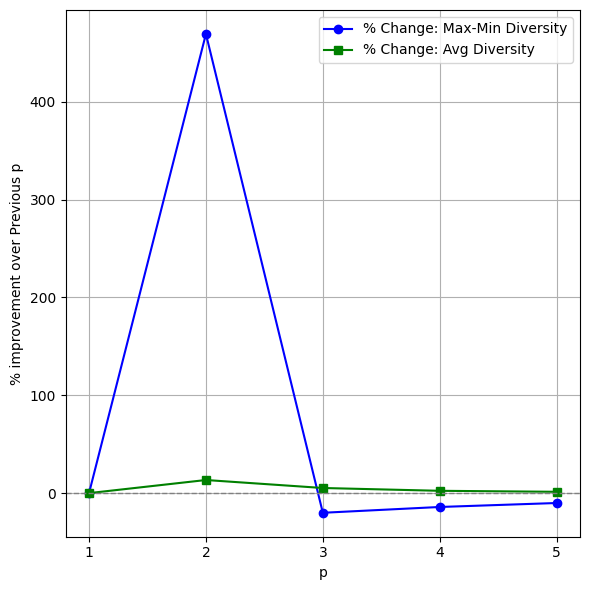

In [ ]:

df_santos = pd.read_csv("stats/santos_benchmark_p_analysis.csv")
plt = analyze_p_treshold(df_santos)
plt.savefig("plots/p_analysis_santos_benchmark.pdf")


Diversity Score Summary and Percentage Changes (from previous p):
p      max-min_avg     avg-div_avg  %Δ max-min   %Δ avg-div   %Δ combined_avg
-----------------------------------------------------------------
1.0    0.00074891      0.12         0.00%        0.00%        0.00%       
2.0    0.00131354      0.13         75.39%       1.63%        38.51%      
3.0    0.00070015      0.13         -46.70%      0.56%        -23.07%     
4.0    0.00048010      0.13         -31.43%      0.37%        -15.53%     
5.0    0.00039230      0.13         -18.29%      -0.01%       -9.15%      


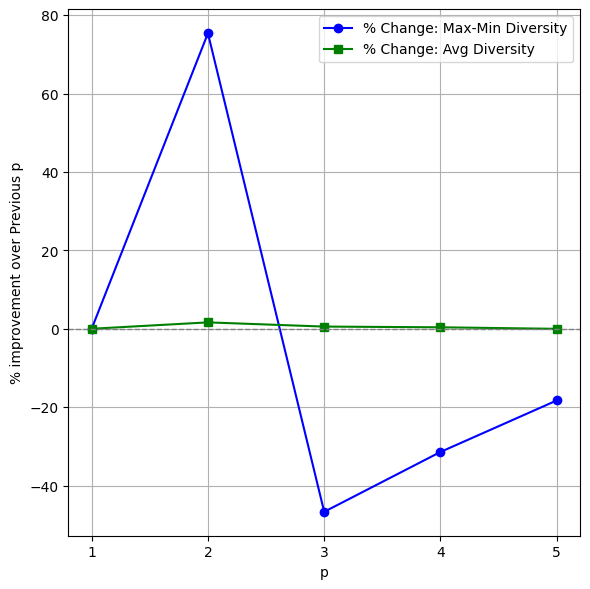

In [17]:
df_ugen = pd.read_csv("stats/ugen_benchmark_p_analysis.csv")
plt = analyze_p_treshold(df_ugen)
plt.show()


/tmp/ipykernel_166058/1974500510.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


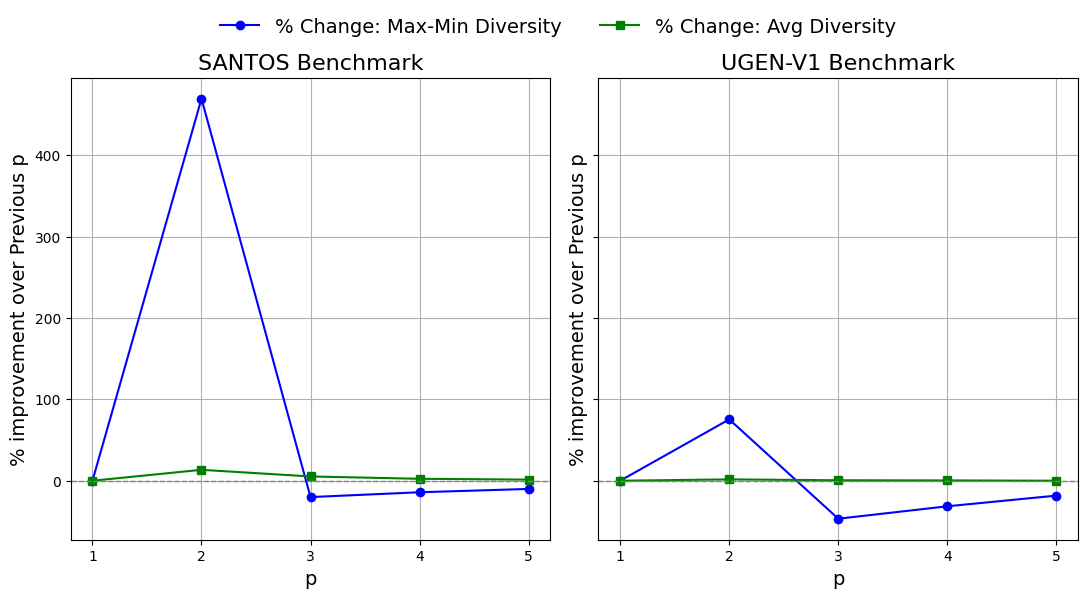

In [21]:
# Generate plot for technical report.
# Create side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=True, gridspec_kw={'wspace': 0.1})

# Call the plotting function for each
analyze_p_treshold_together(df_santos, ax=axes[0])
analyze_p_treshold_together(df_ugen, ax=axes[1])

# Set titles
axes[0].set_title('SANTOS Benchmark', fontsize=16)
axes[1].set_title('UGEN-V1 Benchmark', fontsize=16)

# Create a common legend at the very top
lines, labels = axes[0].get_legend_handles_labels()
fig.legend(
    lines,
    labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.01),  # move legend up
    ncol=2,
    fontsize=14,
    frameon=False
)

# Adjust layout to make space for the legend
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Save plot
plt.savefig("plots/p_threshold_analysis.pdf")
